In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error

In [37]:
PROJECT_ROOT = Path("..")

DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
DATA_LATENT = PROJECT_ROOT / "data" / "latent"
DATA_BACKTESTS = PROJECT_ROOT / "data" / "backtests"

latent_df_base = pd.read_parquet(DATA_LATENT / "fc_vae_latents.parquet")
returns = pd.read_parquet(DATA_PROCESSED / "returns.parquet")

latent_df_base["date"] = pd.to_datetime(latent_df_base["date"])
returns.index = pd.to_datetime(returns.index)

DATA_BACKTESTS.mkdir(parents=True, exist_ok=True)

In [38]:
z_cols = [c for c in latent_df_base.columns if c.startswith("z_")]

z_cols

['z_0', 'z_1', 'z_2', 'z_3', 'z_4', 'z_5', 'z_6', 'z_7']

In [39]:
def performance_stats(r):
    r = r.dropna()

    if len(r) == 0:
        return pd.Series({
            "total_return": np.nan,
            "ann_return": np.nan,
            "ann_vol": np.nan,
            "sharpe": np.nan,
            "max_drawdown": np.nan,
        })

    total_return = (1 + r).prod() - 1
    ann_return = (1 + total_return) ** (252 / len(r)) - 1
    ann_vol = r.std() * np.sqrt(252)
    sharpe = ann_return / ann_vol if ann_vol > 0 else np.nan

    equity = (1 + r).cumprod()
    running_max = equity.cummax()
    drawdown = equity / running_max - 1
    max_drawdown = drawdown.min()

    return pd.Series({
        "total_return": total_return,
        "ann_return": ann_return,
        "ann_vol": ann_vol,
        "sharpe": sharpe,
        "max_drawdown": max_drawdown,
    })

In [40]:
def make_future_returns(returns, horizon):
    """
    For date t, return r_{t+1} + ... + r_{t+horizon}.
    """
    future = pd.DataFrame(0.0, index=returns.index, columns=returns.columns)

    for h in range(1, horizon + 1):
        future += returns.shift(-h)

    return future

In [41]:
def attach_target_return(latent_df, future_returns, target_col):
    rows = []

    for _, row in latent_df[["date", "ticker"]].iterrows():
        date = row["date"]
        ticker = row["ticker"]

        try:
            rows.append(future_returns.loc[date, ticker])
        except KeyError:
            rows.append(np.nan)

    latent_df[target_col] = rows
    latent_df = latent_df.dropna(subset=[target_col]).copy()

    return latent_df

In [42]:
def make_long_short_positions_longform(df, score_col, long_q=0.8, short_q=0.2):
    out = []

    for date, g in df.groupby("date"):
        g = g.copy()

        long_threshold = g[score_col].quantile(long_q)
        short_threshold = g[score_col].quantile(short_q)

        g["position"] = 0
        g.loc[g[score_col] >= long_threshold, "position"] = 1
        g.loc[g[score_col] <= short_threshold, "position"] = -1

        out.append(g)

    return pd.concat(out, axis=0)

In [43]:
def compute_next_day_portfolio_returns(strategy_df, returns, transaction_cost=0.0):
    next_returns = returns.shift(-1)

    next_return_list = []

    for _, row in strategy_df[["date", "ticker"]].iterrows():
        date = row["date"]
        ticker = row["ticker"]

        try:
            next_return_list.append(next_returns.loc[date, ticker])
        except KeyError:
            next_return_list.append(np.nan)

    strategy_df = strategy_df.copy()
    strategy_df["next_return_1d"] = next_return_list
    strategy_df = strategy_df.dropna(subset=["next_return_1d"]).copy()

    strategy_df["gross_asset_return"] = (
        strategy_df["position"] * strategy_df["next_return_1d"]
    )

    daily_gross = (
        strategy_df
        .groupby("date")["gross_asset_return"]
        .mean()
    )

    # egyszerű turnover számítás longformból
    pos_wide = strategy_df.pivot(
        index="date",
        columns="ticker",
        values="position"
    ).fillna(0)

    turnover = pos_wide.diff().abs().mean(axis=1).fillna(0.0)

    daily_net = daily_gross - transaction_cost * turnover

    return daily_net

In [44]:
def make_model(model_name):
    if model_name == "ridge":
        return Pipeline([
            ("scaler", StandardScaler()),
            ("model", Ridge(alpha=10.0))
        ])

    if model_name == "random_forest":
        return RandomForestRegressor(
            n_estimators=200,
            max_depth=5,
            min_samples_leaf=50,
            random_state=42,
            n_jobs=-1
        )

    if model_name == "mlp":
        return Pipeline([
            ("scaler", StandardScaler()),
            ("model", MLPRegressor(
                hidden_layer_sizes=(32, 16),
                activation="relu",
                alpha=1e-3,
                learning_rate_init=1e-3,
                max_iter=300,
                random_state=42
            ))
        ])

    raise ValueError(f"Unknown model_name: {model_name}")

In [45]:
def run_experiment(
    latent_df_base,
    returns,
    horizon,
    model_name,
    long_q=0.8,
    short_q=0.2,
    transaction_cost=0.0,
    train_ratio=0.7
):
    latent_df = latent_df_base.copy()

    target_col = f"target_return_{horizon}d"

    future_returns = make_future_returns(returns, horizon)
    latent_df = attach_target_return(
        latent_df,
        future_returns,
        target_col=target_col
    )

    dates = np.sort(latent_df["date"].unique())
    split_date = dates[int(train_ratio * len(dates))]

    train_mask = latent_df["date"] < split_date
    test_mask = latent_df["date"] >= split_date

    X_train = latent_df.loc[train_mask, z_cols].values
    y_train = latent_df.loc[train_mask, target_col].values

    X_test = latent_df.loc[test_mask, z_cols].values
    y_test = latent_df.loc[test_mask, target_col].values

    model = make_model(model_name)
    model.fit(X_train, y_train)

    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    train_corr = np.corrcoef(y_train, y_pred_train)[0, 1]
    test_corr = np.corrcoef(y_test, y_pred_test)[0, 1]

    score_col = f"score_{model_name}_{horizon}d"
    latent_df[score_col] = model.predict(latent_df[z_cols].values)

    strategy_df = make_long_short_positions_longform(
        latent_df,
        score_col=score_col,
        long_q=long_q,
        short_q=short_q
    )

    portfolio_returns = compute_next_day_portfolio_returns(
        strategy_df,
        returns,
        transaction_cost=transaction_cost
    )

    test_dates = latent_df.loc[test_mask, "date"].unique()

    portfolio_returns_test = portfolio_returns.loc[
        portfolio_returns.index.isin(test_dates)
    ]

    stats = performance_stats(portfolio_returns_test)

    result = {
        "horizon": horizon,
        "model": model_name,
        "split_date": split_date,
        "train_corr": train_corr,
        "test_corr": test_corr,
        "test_mse": mean_squared_error(y_test, y_pred_test),
        **stats.to_dict()
    }

    return result, portfolio_returns_test, strategy_df

In [46]:
HORIZONS = [1, 5, 10, 20]
MODELS = ["ridge", "random_forest", "mlp"]

results = []
returns_dict = {}

for horizon in HORIZONS:
    for model_name in MODELS:
        print(f"Running horizon={horizon}, model={model_name}")

        result, portfolio_returns_test, strategy_df = run_experiment(
            latent_df_base=latent_df_base,
            returns=returns,
            horizon=horizon,
            model_name=model_name,
            long_q=0.8,
            short_q=0.2,
            transaction_cost=0.0,
            train_ratio=0.7
        )

        key = f"{model_name}_{horizon}d"

        results.append(result)
        returns_dict[key] = portfolio_returns_test

Running horizon=1, model=ridge


/Users/holloaron/vae_trading_project/venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/holloaron/vae_trading_project/venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/holloaron/vae_trading_project/venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Users/holloaron/vae_trading_project/venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/holloaron/vae_trading_project/venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/holloaron/vae_trading_project/v

Running horizon=1, model=random_forest
Running horizon=1, model=mlp


/Users/holloaron/vae_trading_project/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/holloaron/vae_trading_project/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/holloaron/vae_trading_project/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/holloaron/vae_trading_project/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/holloaron/vae_trading_project/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/holloaron/vae_trading_project/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/hollo

Running horizon=5, model=ridge


...

/Users/holloaron/vae_trading_project/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/holloaron/vae_trading_project/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/holloaron/vae_trading_project/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/holloaron/vae_trading_project/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/holloaron/vae_trading_project/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/holloaron/vae_trading_project/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/hollo

Running horizon=20, model=ridge


/Users/holloaron/vae_trading_project/venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/holloaron/vae_trading_project/venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/holloaron/vae_trading_project/venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Users/holloaron/vae_trading_project/venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/holloaron/vae_trading_project/venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/holloaron/vae_trading_project/v

Running horizon=20, model=random_forest
Running horizon=20, model=mlp


/Users/holloaron/vae_trading_project/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/holloaron/vae_trading_project/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/holloaron/vae_trading_project/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/holloaron/vae_trading_project/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/holloaron/vae_trading_project/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/holloaron/vae_trading_project/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/hollo

In [47]:
results_df = pd.DataFrame(results)

results_df.sort_values("sharpe", ascending=False)

,horizon,model,split_date,train_corr,test_corr,test_mse,total_return,ann_return,ann_vol,sharpe,max_drawdown
0,1,ridge,2022-03-17,0.039953,0.015071,0.000439,0.126959,0.043903,0.063699,0.689230,-0.107570
9,20,ridge,2022-02-28,0.183128,0.073004,0.008917,0.119814,0.041885,0.066363,0.631145,-0.107684
3,5,ridge,2022-03-14,0.092709,0.037858,0.002215,0.116715,0.040541,0.064496,0.628590,-0.115944
7,10,random_forest,2022-03-09,0.262657,0.036975,0.004468,0.108719,0.037963,0.067027,0.566385,-0.094988
6,10,ridge,2022-03-09,0.132415,0.055081,0.004452,0.102861,0.035980,0.064616,0.556826,-0.118719
11,20,mlp,2022-02-28,0.422241,0.050047,0.010166,0.061614,0.021916,0.045841,0.478085,-0.046547
4,5,random_forest,2022-03-14,0.215158,0.048011,0.002210,0.072578,0.025544,0.061937,0.412425,-0.095015
1,1,random_forest,2022-03-17,0.130239,0.019871,0.000439,0.066069,0.023266,0.063095,0.368742,-0.070886
5,5,mlp,2022-03-14,0.168323,0.000456,0.002570,0.035964,0.012801,0.040562,0.315594,-0.052015
10,20,random_forest,2022-02-28,0.322855,0.040136,0.009019,0.050715,0.018100,0.063489,0.285085,-0.092438


In [48]:
results_df.sort_values("test_corr", ascending=False)

,horizon,model,split_date,train_corr,test_corr,test_mse,total_return,ann_return,ann_vol,sharpe,max_drawdown
9,20,ridge,2022-02-28,0.183128,0.073004,0.008917,0.119814,0.041885,0.066363,0.631145,-0.107684
6,10,ridge,2022-03-09,0.132415,0.055081,0.004452,0.102861,0.035980,0.064616,0.556826,-0.118719
11,20,mlp,2022-02-28,0.422241,0.050047,0.010166,0.061614,0.021916,0.045841,0.478085,-0.046547
4,5,random_forest,2022-03-14,0.215158,0.048011,0.002210,0.072578,0.025544,0.061937,0.412425,-0.095015
10,20,random_forest,2022-02-28,0.322855,0.040136,0.009019,0.050715,0.018100,0.063489,0.285085,-0.092438
3,5,ridge,2022-03-14,0.092709,0.037858,0.002215,0.116715,0.040541,0.064496,0.628590,-0.115944
7,10,random_forest,2022-03-09,0.262657,0.036975,0.004468,0.108719,0.037963,0.067027,0.566385,-0.094988
1,1,random_forest,2022-03-17,0.130239,0.019871,0.000439,0.066069,0.023266,0.063095,0.368742,-0.070886
0,1,ridge,2022-03-17,0.039953,0.015071,0.000439,0.126959,0.043903,0.063699,0.689230,-0.107570
8,10,mlp,2022-03-09,0.295013,0.007216,0.005115,0.000813,0.000293,0.043051,0.006814,-0.065768


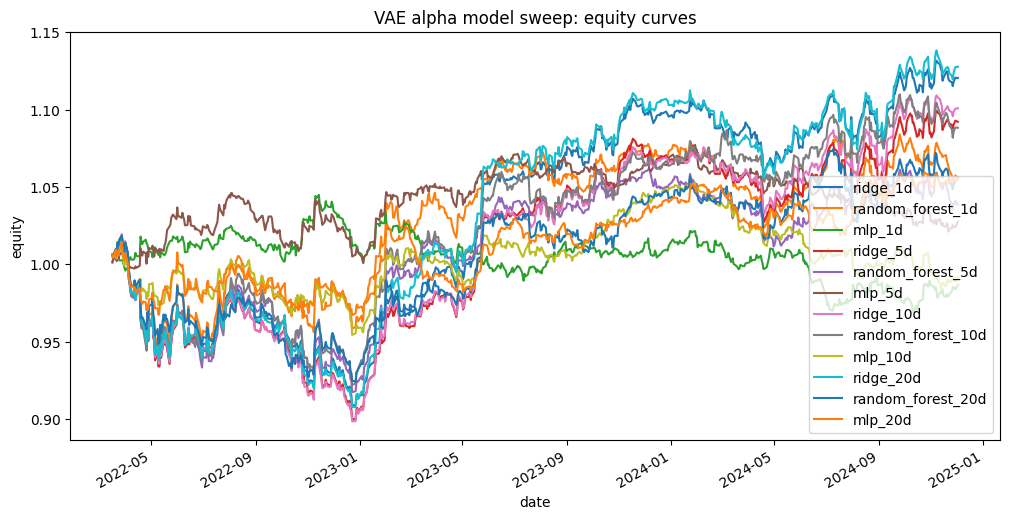

In [49]:
returns_comparison = pd.concat(returns_dict, axis=1).dropna()

equity = (1 + returns_comparison).cumprod()

equity.plot(
    figsize=(12, 6),
    title="VAE alpha model sweep: equity curves"
)

plt.ylabel("equity")
plt.show()

In [50]:
sharpe_table = results_df.pivot(
    index="horizon",
    columns="model",
    values="sharpe"
)

sharpe_table

model,mlp,random_forest,ridge
horizon,,,
1,-0.164028,0.368742,0.689230
5,0.315594,0.412425,0.628590
10,0.006814,0.566385,0.556826
20,0.478085,0.285085,0.631145


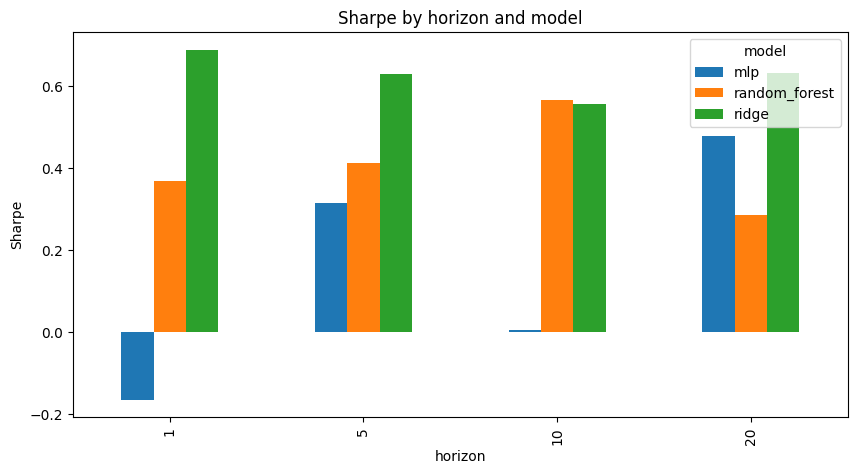

In [51]:
sharpe_table.plot(
    kind="bar",
    figsize=(10, 5),
    title="Sharpe by horizon and model"
)

plt.ylabel("Sharpe")
plt.show()

In [52]:
results_df.to_csv(DATA_BACKTESTS / "vae_alpha_sweep_results.csv", index=False)
returns_comparison.to_parquet(DATA_BACKTESTS / "vae_alpha_sweep_returns.parquet")

In [53]:
results_df.sort_values("sharpe", ascending=False)

,horizon,model,split_date,train_corr,test_corr,test_mse,total_return,ann_return,ann_vol,sharpe,max_drawdown
0,1,ridge,2022-03-17,0.039953,0.015071,0.000439,0.126959,0.043903,0.063699,0.689230,-0.107570
9,20,ridge,2022-02-28,0.183128,0.073004,0.008917,0.119814,0.041885,0.066363,0.631145,-0.107684
3,5,ridge,2022-03-14,0.092709,0.037858,0.002215,0.116715,0.040541,0.064496,0.628590,-0.115944
7,10,random_forest,2022-03-09,0.262657,0.036975,0.004468,0.108719,0.037963,0.067027,0.566385,-0.094988
6,10,ridge,2022-03-09,0.132415,0.055081,0.004452,0.102861,0.035980,0.064616,0.556826,-0.118719
11,20,mlp,2022-02-28,0.422241,0.050047,0.010166,0.061614,0.021916,0.045841,0.478085,-0.046547
4,5,random_forest,2022-03-14,0.215158,0.048011,0.002210,0.072578,0.025544,0.061937,0.412425,-0.095015
1,1,random_forest,2022-03-17,0.130239,0.019871,0.000439,0.066069,0.023266,0.063095,0.368742,-0.070886
5,5,mlp,2022-03-14,0.168323,0.000456,0.002570,0.035964,0.012801,0.040562,0.315594,-0.052015
10,20,random_forest,2022-02-28,0.322855,0.040136,0.009019,0.050715,0.018100,0.063489,0.285085,-0.092438


In [54]:
results_df.sort_values("test_corr", ascending=False)

,horizon,model,split_date,train_corr,test_corr,test_mse,total_return,ann_return,ann_vol,sharpe,max_drawdown
9,20,ridge,2022-02-28,0.183128,0.073004,0.008917,0.119814,0.041885,0.066363,0.631145,-0.107684
6,10,ridge,2022-03-09,0.132415,0.055081,0.004452,0.102861,0.035980,0.064616,0.556826,-0.118719
11,20,mlp,2022-02-28,0.422241,0.050047,0.010166,0.061614,0.021916,0.045841,0.478085,-0.046547
4,5,random_forest,2022-03-14,0.215158,0.048011,0.002210,0.072578,0.025544,0.061937,0.412425,-0.095015
10,20,random_forest,2022-02-28,0.322855,0.040136,0.009019,0.050715,0.018100,0.063489,0.285085,-0.092438
3,5,ridge,2022-03-14,0.092709,0.037858,0.002215,0.116715,0.040541,0.064496,0.628590,-0.115944
7,10,random_forest,2022-03-09,0.262657,0.036975,0.004468,0.108719,0.037963,0.067027,0.566385,-0.094988
1,1,random_forest,2022-03-17,0.130239,0.019871,0.000439,0.066069,0.023266,0.063095,0.368742,-0.070886
0,1,ridge,2022-03-17,0.039953,0.015071,0.000439,0.126959,0.043903,0.063699,0.689230,-0.107570
8,10,mlp,2022-03-09,0.295013,0.007216,0.005115,0.000813,0.000293,0.043051,0.006814,-0.065768
